In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks

folder = Path("Data/GBand/20260116_MF2_rotation_test/MLOG/")

class schema:
    #data = "data"
    freq = "freq"
    #freq_ = 'freq_data' 
    trans = 'data'
    angle = 'deg'
    #phase = 'phase_data' 
    #realdata = 'real_data' 
    #imagdata = 'imag_data' 
    #freqfit = 'freq_fit' 
    #transfit = 'trans_fit' 
    #realfit = 'real_fit' 
    #imagfit ='imag_fit' 
    #n = 'fit_n' 
    #loss = 'fit_los' 
    #nerr = 'fit_n_err'
    #losserr = 'fit_los_err'
    #transdiff = 'trans_diff'

def importfile(file):
    f = np.load(file)
    freq = f[schema.freq]
    data = f[schema.trans]
    angle = f[schema.angle]
    
    df = pd.DataFrame({schema.freq: freq, 
                       schema.trans: data,
                       schema.angle: angle})
    return df

def get_integrated_mlog():
    folder = Path("Data/GBand/20260116_MF2_rotation_test/MLOG/")
    integrated_transmission = []

    for npz_file in folder.glob("*.npz"):
        file = importfile(npz_file)

        freq = file.iloc[:, 0].to_numpy()
        trans = file.iloc[:, 1].to_numpy()
        #plt.plot(freq, trans)
        #plt.show()

        integral = np.trapezoid(trans, freq)
        integrated_transmission.append(integral)

    return np.array(integrated_transmission)

def get_integrated_transmission():
    folder = Path("Data/Transmission/")
    integrated_transmission = []

    for txt_file in folder.glob("*.txt"):
        file = pd.read_csv(
            txt_file,
            sep=",",
            header=1
        )

        freq = file.iloc[:, 0].to_numpy()
        trans = file.iloc[:, 1].to_numpy()
        #plt.plot(freq, trans)
        #plt.show()

        integral = np.mean(trans)
        integrated_transmission.append(integral)

    return np.array(integrated_transmission)


In [20]:
test_real = np.load("Data/GBand/20260116_MF2_rotation_test/REAL/G_REAL_0deg_1000_1001_20260116143800.npz")
print(test_real)

NpzFile 'Data/GBand/20260116_MF2_rotation_test/REAL/G_REAL_0deg_1000_1001_20260116143800.npz' with keys: freq, data, deg


In [29]:
test_real = importfile("Data/GBand/20260116_MF2_rotation_test/MLOG/G_MLOG_0deg_1000_1001_20260116143800.npz")
display(test_real)
print(test_real.iloc[:,0])

,freq,data,deg
0,140.00,-5.665506,0
1,140.08,-5.585406,0
2,140.16,-5.476388,0
3,140.24,-5.396511,0
4,140.32,-5.330876,0
...,...,...,...
996,219.68,-4.270587,0
997,219.76,-4.226209,0
998,219.84,-4.197365,0
999,219.92,-4.089826,0


0       140.00
1       140.08
2       140.16
3       140.24
4       140.32
         ...  
996     219.68
997     219.76
998     219.84
999     219.92
1000    220.00
Name: freq, Length: 1001, dtype: float64


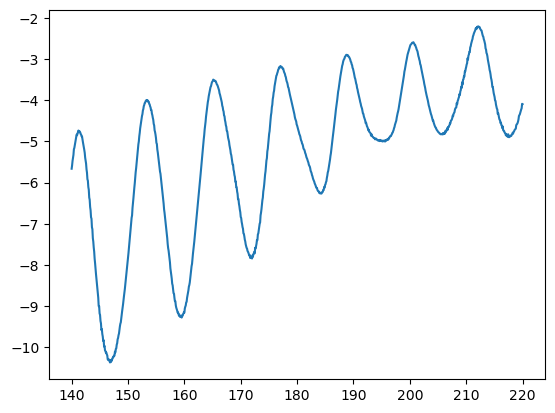

In [30]:
plt.plot(test_real.iloc[:,0], test_real.iloc[:,1])

Text(0.5, 0, 'Angle (deg)')

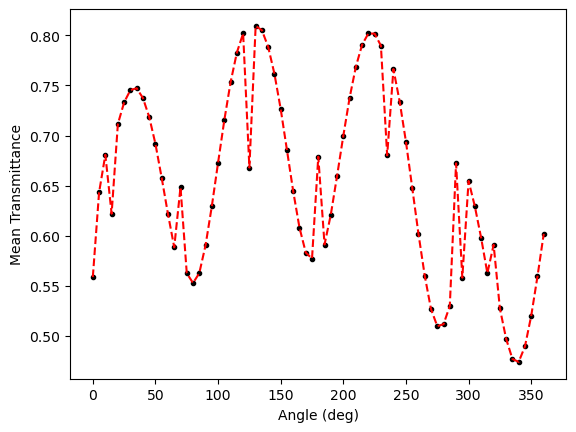

In [98]:
transmission = get_integrated_transmission()
peaks, properties = find_peaks(transmission)
plt.plot(np.linspace(0,360,73), transmission, "k.")
plt.plot(np.linspace(0,360,73), transmission, "r--")
plt.ylabel("Mean Transmittance")
plt.xlabel("Angle (deg)")
#plt.plot(peaks*(360/73), transmission[peaks], "ro")


[ 2  7 14 24 26 36 44 48 58 60 64]
